# UNSupervised Spatial Graph Network for Soil Erosion

This notebook executes **Method 1 (Hybrid GCN)** engineered with **Soil Cohesiveness (K-Factor)** for precise erosion susceptibility mapping.

## 1. Import Required Libraries
Importing data manipulation, spatial math, and visualization tools.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Note: PyTorch & PyTorch Geometric (PyG) will be imported later for the Graph Network
print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load the Spatial Dataset
Loading the merged Woreda dataset from Excel.

In [2]:
file_path = 'Merged_Woredas_All.xlsx'
print(f'Loading {file_path}...')
df = pd.read_excel(file_path)
print(f'Dataset Loaded! Shape: {df.shape}')
display(df.head(3))

Loading Merged_Woredas_All.xlsx...
Dataset Loaded! Shape: (255029, 19)


,Latitude,Longitude,Aspect (Degree),Drainage Density (m),Elevation (m),Ferrous Materials,Geology_Formation,Land_Use,NDVI_Value,Plan Curvature,Profile Curvature,Rainfall (mm),Slope (Degree),Soil Type,SPI,TPI,TRI,TWI,Woreda
0,8.963316,39.278868,217.404999,1251.020020,1907,Minerals,Nazret Series,Cropland,0.092494,2.262080e+09,-3.353920e+09,1046.229981,1.656543,Eutric Cambisol,0.768535,13.000000,0.375000,1.47702,Menjar
1,10.072387,38.971077,37.303902,0.000000,1534,Minerals,Antalo Formation,Cropland,0.154723,-1.597660e+09,1.714340e+09,1038.569946,57.082699,Eutric Cambisol,4.151180,-51.415001,0.587298,-6.52941,Merabete
2,8.936511,39.438121,341.565002,1183.369995,1740,Minerals,Nazret Series,Cropland,0.094457,-1.152000e+08,4.608000e+08,931.596008,0.244843,Eutric Regosol,3.342790,-1.333370,0.444443,4.99991,Menjar


## 3. Engineer Soil Cohesiveness (K-Factor)
Mapping the 'sticking together capacity' of the soil based on geological FAO classifications. Clays stick together (Low K), while Sands erode instantly (High K).

In [3]:
cohesion_mapping = {
    'Pellic Vertisol': 0.15,   # Heavy clay, highly cohesive, safe
    'Ferralic Cambisol': 0.20, # Weathered, relatively stable
    'Eutric Cambisol': 0.25,   # Loamy, moderate cohesiveness
    'Calcic Xerosol': 0.30,    # Dry/arid soil, moderate-low
    'Eutric Regosol':  0.40,   # Unconsolidated materials, dangerous
    'Cambie Arenosol': 0.45    # Sandy soil, VERY LOW cohesiveness (erodes instantly)
}

df['Soil Type'] = df['Soil Type'].fillna('Eutric Cambisol')
df['K_Factor'] = df['Soil Type'].map(cohesion_mapping)

print('Mapped Soil Cohesiveness. Sample:')
display(df[['Soil Type', 'K_Factor']].head(5))

Mapped Soil Cohesiveness. Sample:


,Soil Type,K_Factor
0,Eutric Cambisol,0.25
1,Eutric Cambisol,0.25
2,Eutric Regosol,0.40
3,Ferralic Cambisol,0.20
4,Eutric Cambisol,0.25


## 3b. Scientific Preprocessing: Spatial GIS Interpolation
We use **Spatial Interpolation (Inverse Distance Weighting via KNN)** based strictly on geographic coordinates (Lat/Lon). If a point is missing data, its exact neighbors determine the value, strictly following Tobler's First Law of Geography.

In [5]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

continuous_cols = ['Elevation (m)', 'Slope (Degree)', 'Rainfall (mm)', 'NDVI_Value', 
                   'TWI', 'SPI', 'TRI', 'Plan Curvature', 'Profile Curvature', 'Drainage Density (m)']

print('Scanning for missing environmental features...')
missing_counts = df[continuous_cols].isnull().sum()

if missing_counts.sum() > 0:
    print('Executing Scientific Spatial Interpolation (IDW)...')
    coords = df[['Latitude', 'Longitude']].values
    for col in continuous_cols:
        if df[col].isnull().any():
            missing_mask = df[col].isnull()
            known_mask = ~missing_mask
            
            X_known, y_known = coords[known_mask], df.loc[known_mask, col].values
            X_missing = coords[missing_mask]
            
            spatial_imputer = KNeighborsRegressor(n_neighbors=5, weights='distance', n_jobs=-1)
            spatial_imputer.fit(X_known, y_known)
            df.loc[missing_mask, col] = spatial_imputer.predict(X_missing)
            print(f'Interpolated missing geometry for: {col}')
else:
    print('No missing values found! Skipping interpolation.')


Scanning for missing environmental features...
Executing Scientific Spatial Interpolation (IDW)...
Interpolated missing geometry for: SPI
Interpolated missing geometry for: TRI
Interpolated missing geometry for: Drainage Density (m)


## 4. Generate Semi-Supervised Target Variable (RUSLE Seed)
We calculate a physical risk score using **Slope * Rainfall * K_Factor / NDVI**.
We extract only the **Top 5% (Severe Risk, Label 1)** and **Bottom 5% (Safe, Label 0)** to train the Graph Network. We mask the remaining 90% as missing (-1 or NaN) for the GCN to predict.

## 5. Circular Aspect & Feature Scaling
Converting continuous variables into safe mathematical spaces for Deep Learning.

In [6]:
import numpy as np
df['Aspect_Sin'] = np.sin(np.radians(df['Aspect (Degree)']))
df['Aspect_Cos'] = np.cos(np.radians(df['Aspect (Degree)']))

# ---------------------------------------------------------
# CRITICAL FIX: ETHIOPIAN PHYSICS-INFORMED HARD BOUNDING
# ---------------------------------------------------------
features_to_scale = ['Elevation (m)', 'Slope (Degree)', 'Rainfall (mm)', 'NDVI_Value', 'TWI', 'SPI', 'TRI', 'Plan Curvature', 'Profile Curvature', 'Drainage Density (m)']

ethiopian_physical_bounds = {
    'Elevation (m)': (-150, 4600),   # Danakil Depression to Ras Dashen
    'Slope (Degree)': (0, 90),       # Physical limit of gravity
    'Rainfall (mm)': (0, 3000),      # Extreme bounds for Amhara woredas
    'NDVI_Value': (-1.0, 1.0)        # Spectral math limits
}

print('--- ETHIOPIAN TOPOGRAPHICAL SCANNER REPORT ---')
for col in features_to_scale:
    col_max = df[col].max()
    col_min = df[col].min()
    
    if col in ethiopian_physical_bounds:
        hard_min, hard_max = ethiopian_physical_bounds[col]
        if col_max > hard_max or col_min < hard_min:
            print(f'🚨 PHYSICS VIOLATION DETECTED in {col}!')
            print(f'   -> Recorded range: [{col_min:.2f} to {col_max:.2f}]')
            print(f'   -> Hard-clipping to Ethiopian geographic limits: [{hard_min} to {hard_max}]')
        df[col] = df[col].clip(lower=hard_min, upper=hard_max)
    else:
        p_001, p_999 = df[col].quantile(0.001), df[col].quantile(0.999)
        df[col] = df[col].clip(lower=p_001, upper=p_999)

print('\nFalse anomalies eliminated! Applying MinMaxScaler...')
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# CATEGORICAL ENGINEERING (One-Hot Encoding)
import pandas as pd
df['Geology_Formation'] = df['Geology_Formation'].fillna('Unknown_Geo')
df['Land_Use'] = df['Land_Use'].fillna('Unknown_LU')
cat_encoded = pd.get_dummies(df[['Geology_Formation', 'Land_Use']], drop_first=True)
cat_columns = cat_encoded.columns.tolist()
df = pd.concat([df, cat_encoded], axis=1)


--- ETHIOPIAN TOPOGRAPHICAL SCANNER REPORT ---
🚨 PHYSICS VIOLATION DETECTED in Slope (Degree)!
   -> Recorded range: [0.00 to 304.40]
   -> Hard-clipping to Ethiopian geographic limits: [0 to 90]

False anomalies eliminated! Applying MinMaxScaler...


## 6. Spatial Graph Construction (Adj Matrix via KDTree)
We use the physical `Latitude` and `Longitude` of every row to form a topological network. Each point connects to its closest geographical neighbors (e.g., K=8 for spatial grids), allowing the neural network to understand how water and gravity flow across the landscape.

In [7]:
from scipy.spatial import cKDTree
import torch

# Extract coordinates
coords = df[['Longitude', 'Latitude']].values

print('Building KDTree for Spatial Graph...')
# K=9 because kdtree returns the point itself as the first neighbor
tree = cKDTree(coords)
distances, indices = tree.query(coords, k=9)

# Construct Edge Index format for PyTorch [2, num_edges]
edge_list = []
for i in range(len(indices)):
    for j in range(1, 9): # Skip the first one (itself)
        neighbor_idx = indices[i][j]
        edge_list.append([i, neighbor_idx])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
print(f'Graph constructed! Total nodes: {len(coords)}, Total edges: {edge_index.shape[1]}')

Building KDTree for Spatial Graph...
Graph constructed! Total nodes: 255029, Total edges: 2040232


## Method 1: Fully Unsupervised Clustering (K-Means)
Because this is fully Unsupervised, we have **removed the RUSLE logic and the Graph Edges**. 
We are feeding the pure, normalized feature matrix directly into an unsupervised K-Means engine. 
We ask the algorithm to naturally sever the data into `k=3` distinct clusters without any hints about physics.

In [8]:
from sklearn.cluster import KMeans
import numpy as np

print('Executing Fully Unsupervised K-Means Machine Learning...')

# 1. Define the exact same normalized features we fed our GCN
base_features = ['K_Factor', 'Elevation (m)', 'Slope (Degree)', 'Rainfall (mm)', 
                 'NDVI_Value', 'TWI', 'SPI', 'TRI', 'Plan Curvature', 'Profile Curvature', 
                 'Aspect_Sin', 'Aspect_Cos', 'Drainage Density (m)']
all_features = base_features + cat_columns
X_unsupervised = df[all_features].fillna(0).values

# 2. Run the blind Unsupervised Algorithm
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df['Unsupervised_Cluster'] = kmeans.fit_predict(X_unsupervised)

print('Blind Clustering Complete! Distribution:')
print(df['Unsupervised_Cluster'].value_counts())


Executing Fully Unsupervised K-Means Machine Learning...
Blind Clustering Complete! Distribution:
Unsupervised_Cluster
0    100859
2     83569
1     70601
Name: count, dtype: int64


## Physics Verification of the Blind Clusters
Since K-Means is mathematically blind to physics, we must inspect the groups it created. 
Did it successfully discover the dangers of Slope and Rain? Or did it blindly sort the data by something irrelevant (like Elevation) due to the lack of spatial edges and RUSLE anchors?

C:\Users\SURA\AppData\Local\Temp\ipykernel_22228\3626804340.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Unsupervised_Cluster', data=df, palette='viridis')


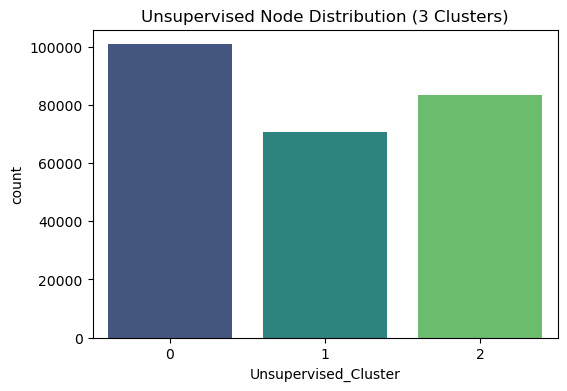


--- PROVING UNSUPERVISED PHYSICAL LOGIC ---


,Slope (Degree),Rainfall (mm),SPI,K_Factor,Elevation (m),NDVI_Value
Unsupervised_Cluster,,,,,,
0,0.190885,0.312635,0.004055,0.258617,0.346296,0.496444
1,0.204939,0.305342,0.002952,0.261942,0.391704,0.491937
2,0.203742,0.257982,0.002614,0.272123,0.382476,0.486491



💡 Analysis: Look at the table above. Did Cluster 0, 1, or 2 successfully isolate High-Slope + High-Rain areas the way the GCN did? Or is the difference between them mostly just confusing Elevation/NDVI shifts?


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Unsupervised_Cluster', data=df, palette='viridis')
plt.title('Unsupervised Node Distribution (3 Clusters)')
plt.show()

print('\n--- PROVING UNSUPERVISED PHYSICAL LOGIC ---')
# Because K-Means does not know what is dangerous, it just names them 0, 1, and 2.
# We must look at the averages to see if they make physical sense!
unsupervised_verification = df.groupby('Unsupervised_Cluster')[['Slope (Degree)', 'Rainfall (mm)', 'SPI', 'K_Factor', 'Elevation (m)', 'NDVI_Value']].mean()
display(unsupervised_verification)

print('\n💡 Analysis: Look at the table above. Did Cluster 0, 1, or 2 successfully isolate High-Slope + High-Rain areas the way the GCN did? Or is the difference between them mostly just confusing Elevation/NDVI shifts?')
